<a href="https://colab.research.google.com/github/latenightcoder1/design_patterns/blob/main/week3/Suraj_Week_3_Day_1_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 Day 1

Welcome to Google Colab - using free and powerful compute in the cloud.

Google Colab gives you a remote Notebook-style browser window on to a machine, and you run code "locally" on that machine.

## Benefits of Colab

1. Free access to T4 GPUs!
2. Easy ability to share code and collaborate on it
3. Everyone gets to use identical code - no environment differences

## Downsides of Colab

1. As it's free, Google reserves the right to bump you off the box at any point ("reset the runtime"), and this happens most quickly if no code is running. They can also downgrade you from a T4 to a CPU-only box. Sometimes this happens silently. You need to start everything again from the top. Paid plans last longer.
2. You need to pip install packages every single time (but no pip installs today)
3. There's some latency - it's not as interactive as coding on your own box

## Survival Guide

1. Always start by pressing the drop down arrow by Connect on the top right, and "Connect to a hosted runtime: T4"
2. From that dropdown, "View Resources" to check you have a GPU and monitor memory
3. If things go awry, Runtime >> Disconnect and Delete Runtime, Connect again, and then run cells from the top
4. Always run the pip installs! Ignore pip dependency errors.

Runtime >> Restart session: this restarts the Python Kernel, but pip packages remain installed and the disk remains the same.

Runtime >> Diconnect and delete session. This wipes everything.

In [ ]:
!pip install -q --upgrade transformers==4.56.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 78.3 MB/s eta 0:00:00


In [ ]:
# Let's check the GPU - it should be a Tesla T4

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)
  if gpu_info.find('Tesla T4') >= 0:
    print("Success - Connected to a T4")
  else:
    print("NOT CONNECTED TO A T4")

Thu Nov  6 20:17:47 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Connecting Hugging Face

You'll need to log in to the HuggingFace hub if you've not done so before.

1. If you haven't already done so, create a **free** HuggingFace account at https://huggingface.co and navigate to Settings from the user menu on the top right. Then Create a new API token, giving yourself write permissions.  

**IMPORTANT** when you create your HuggingFace API key, please be sure to select WRITE permissions for your key by clicking on the WRITE tab, otherwise you may get problems later. Not "fine-grained" but "write".

2. Back here in colab, press the "key" icon on the side panel to the left, and add a new secret:  
  In the name field put `HF_TOKEN`  
  In the value field put your actual token: `hf_...`  
  Ensure the notebook access switch is turned ON.

3. Execute the cell below to log in. You'll need to do this on each of your colabs. It's a really useful way to manage your secrets without needing to type them into colab.

In [ ]:
from huggingface_hub import login
from google.colab import userdata


hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

text_encoder/model.fp16.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

text_encoder_2/model.fp16.safetensors:   0%|          | 0.00/1.39G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/4 [00:00<?, ?it/s]

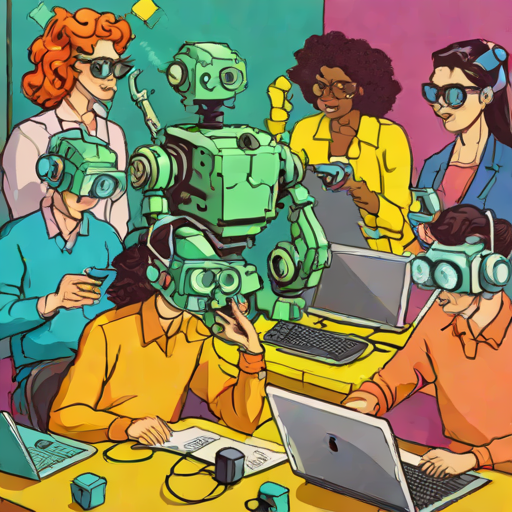

In [ ]:
from IPython.display import display
from diffusers import AutoPipelineForText2Image
import torch
# IPython.display.display: Lets you display images or other rich media directly in a Jupyter notebook.
# diffusers.AutoPipelineForText2Image: Automatically loads a text-to-image generation pipeline (like Stable Diffusion or SDXL) from a pre-trained model.
# torch: PyTorch library, used here for handling tensor computations and moving models to GPU. PyTorch library, handles tensors and GPU computations.

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
# from_pretrained: Downloads and loads a pre-trained model named "stabilityai/sdxl-turbo".
# torch_dtype=torch.float16: Loads the model in half-precision (float16) to save memory and speed up inference.
# variant="fp16": Confirms we want the float16 variant of the model.
pipe.to("cuda")
# Sends the model to the GPU (if available) for faster processing. "cuda" is the GPU device in PyTorch.
prompt = "A class of students learning AI engineering in a vibrant pop-art style"
# This is the text description that the model will turn into an image.
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
# num_inference_steps=4: The number of steps the model takes to generate the image. Fewer steps = faster but lower quality.
# guidance_scale=0.0: Controls how closely the image follows the prompt. 0.0 means minimal guidance (more random/freestyle output), higher values make the image more aligned with the prompt.
# .images[0]: pipe() returns a batch of images, and [0] selects the first image.
display(image)
# Shows the generated image directly in the notebook.


In [ ]:
# Restart the kernel

import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

text_encoder_2/model.fp16.safetensors:   0%|          | 0.00/1.39G [00:00<?, ?B/s]

text_encoder/model.fp16.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

vae_1_0/diffusion_pytorch_model.fp16.saf(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/30 [00:00<?, ?it/s]

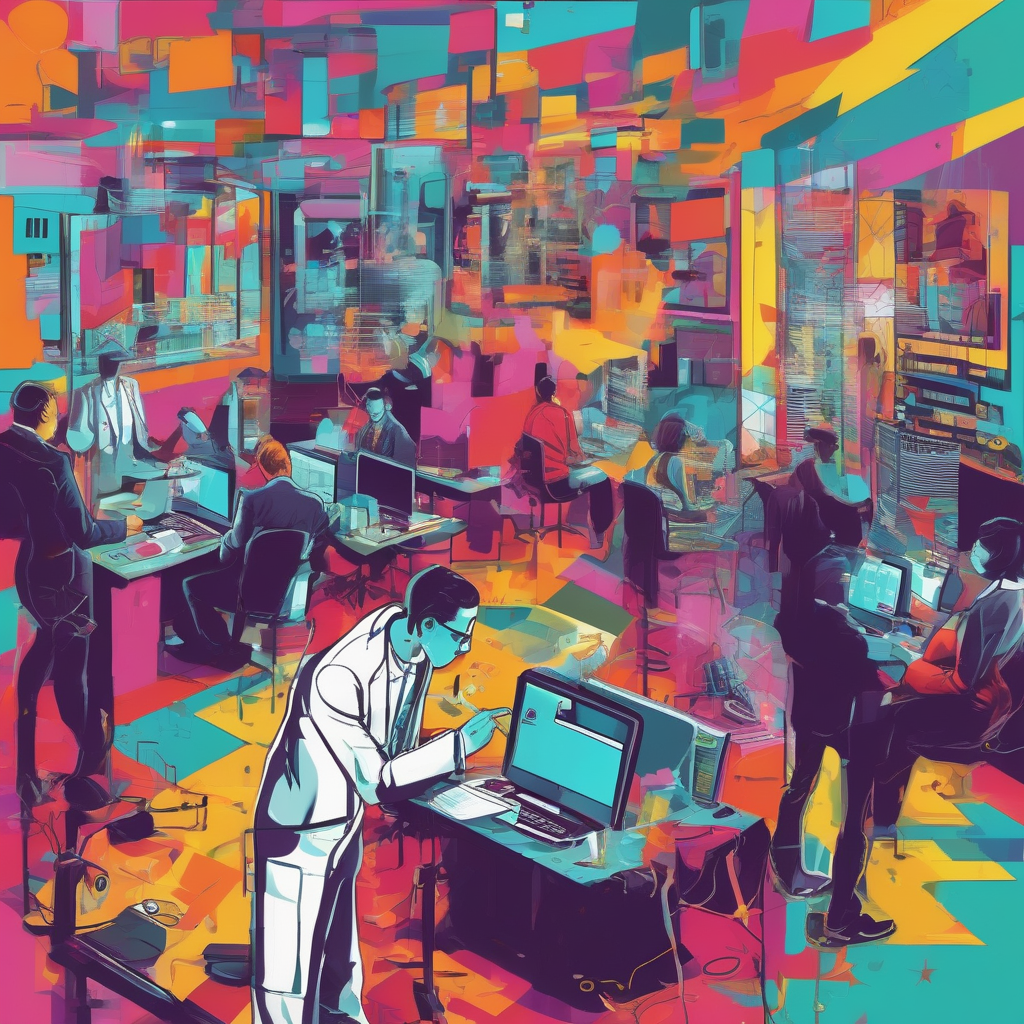

In [ ]:
from IPython.display import display
from diffusers import DiffusionPipeline
import torch

#display: Shows images in a Jupyter notebook.
# DiffusionPipeline: The core class in diffusers to run diffusion models (like Stable Diffusion).
# torch: PyTorch library, handles tensors and GPU computations.

pipe = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, use_safetensors=True, variant="fp16")
# DiffusionPipeline.from_pretrained(): Loads a pre-trained model from Hugging Face.
# Model name: "stabilityai/stable-diffusion-xl-base-1.0" — this is the SDXL Base model.
# torch_dtype=torch.float16: Loads the model in half-precision (less memory, faster).
# use_safetensors=True: Uses the safetensors format, which is faster and more secure than standard PyTorch .pt files.
# variant="fp16": Ensures float16 weights are loaded.

pipe.to("cuda")
# Sends the model to GPU for faster computation.

prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"

image = pipe(prompt=prompt, num_inference_steps=30).images[0]
# num_inference_steps=30: Number of denoising steps. More steps → higher quality, slower generation.
# .images[0]: Picks the first generated image from the batch.

display(image)


In [ ]:
# Restart the kernel

import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

this is an advanced Stable Diffusion XL (SDXL) setup, where two specialized models — Base and Refiner — work together to produce a higher-quality image

Stable Diffusion XL (SDXL) has two cooperating models:

Base model — does the heavy lifting: turns text into a rough but coherent image with most of the composition, structure, and colors.

Refiner model — cleans up and sharpens the Base output, adding fine details, texture, lighting, etc.

They’re designed to run sequentially — the Base handles the first (high-noise) part of the diffusion, and the Refiner handles the later (low-noise) part.

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model_index.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/4.52G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

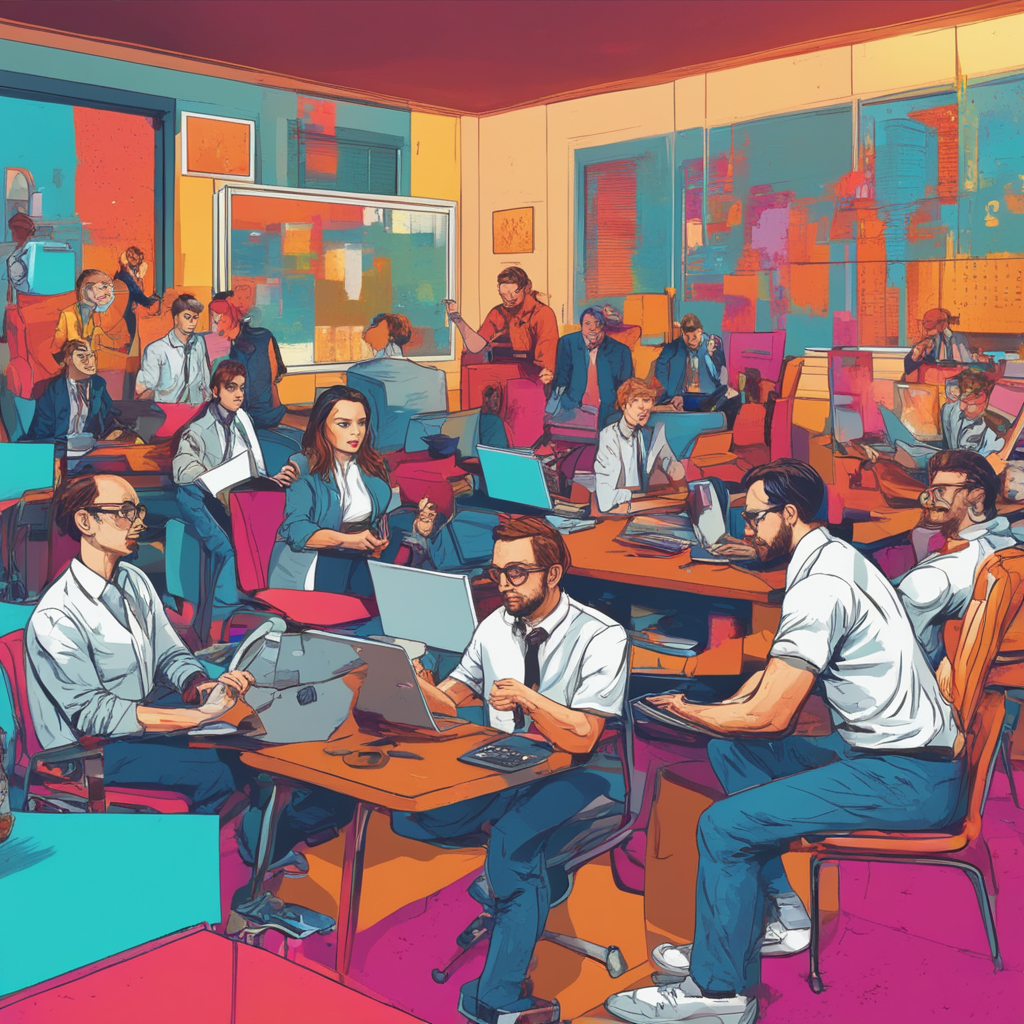

In [ ]:
from diffusers import DiffusionPipeline
import torch
#DiffusionPipeline = main class that loads and runs diffusion models.
# torch = used for GPU computation.

base = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, variant="fp16", use_safetensors=True)
base.to("cuda")
# Loads the SDXL Base model.
# Uses half-precision (float16) for speed/memory efficiency.
# Sends it to GPU.
# This pipeline will handle the first 80% of the diffusion process (coarse generation).

refiner = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-refiner-1.0", text_encoder_2=base.text_encoder_2, vae=base.vae, torch_dtype=torch.float16, use_safetensors=True, variant="fp16",)
refiner.to("cuda")

# Loads the Refiner model, which enhances Base output.
# It reuses two components from the Base model:
# text_encoder_2 → the text embedding module (so both models interpret prompts identically)
# vae → the decoder that turns latents into images.
# Also uses float16 + GPU.
# The Refiner will process the remaining 20% of denoising (fine details).

# Define how many steps and what % of steps to be run on each experts (80/20) here
n_steps = 40
high_noise_frac = 0.8
#Total denoising steps = 40
# The Base model runs 80% (32 steps), and the Refiner runs 20% (8 steps).

prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"

# run both experts
image = base(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_end=high_noise_frac,
    output_type="latent",
).images
# denoising_end=0.8 → run until 80% of diffusion steps are done.
# output_type="latent" → don’t decode to an RGB image yet; return latent representation (for Refiner to continue).
# The result (image) is a latent tensor, not a visible image yet.

image = refiner(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_start=high_noise_frac,
    image=image,
).images[0]

# denoising_start=0.8 → continue from where the Base left off.
# image=image → take Base’s latent as input.
# num_inference_steps=40 again ensures consistent noise schedule.
# The Refiner denoises the last 20% → producing a final high-quality image.

display(image)

In [ ]:
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

In [ ]:
!pip install --upgrade datasets==3.6.0

this one is about Text-to-Speech (TTS) using Hugging Face’s transformers and datasets libraries.

This code takes a text prompt and uses a pre-trained neural TTS model (microsoft/speecht5_tts) to generate speech audio in the voice of a particular speaker from a dataset of voice embeddings.

In [ ]:
from transformers import pipeline
from datasets import load_dataset
import soundfile as sf
import torch
from IPython.display import Audio
# pipeline → high-level interface from Transformers for tasks like text-to-speech, translation, summarization, etc.
# load_dataset → loads pre-built datasets from Hugging Face Hub.
# soundfile (sf) → can save/play audio (not directly used here but useful).
# torch → for handling tensors and moving computations to GPU.
# Audio → Jupyter helper to play audio directly in the notebook.

synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts", device='cuda')
# Creates a text-to-speech pipeline using Microsoft’s SpeechT5 model.
# device='cuda' → run on GPU if available (much faster).
# Under the hood, SpeechT5 consists of:
  # a text encoder (converts words → latent representations),
  # a decoder (generates mel-spectrograms),
  # and a vocoder (turns spectrograms → waveform).
embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True)
# Loads the CMU-Arctic x-vectors dataset → a collection of speaker embeddings.
# Each xvector encodes a speaker’s voice characteristics (pitch, timbre, accent, etc.).
# trust_remote_code=True → allows any dataset-specific code on the hub to run.
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)
# Selects the speaker at index 7306.
# Converts that NumPy array into a PyTorch tensor.
# unsqueeze(0) adds a batch dimension, so shape becomes (1, embedding_size).
# This tells the TTS model “speak in this particular voice.”
speech = synthesiser("Hi to an artificial intelligence engineer, on the way to mastery!", forward_params={"speaker_embeddings": speaker_embedding})
# Feeds text to the synthesizer.
# forward_params passes the speaker embedding into the model so the generated audio mimics that speaker’s voice.
# The output, speech, is a dictionary that typically contains:
  # "audio" → raw waveform samples (NumPy array)
  # "sampling_rate" → sample rate (e.g., 16 kHz)
Audio(speech["audio"], rate=speech["sampling_rate"])
# Wraps the waveform in an IPython.display.Audio object → plays directly in the notebook.

Device set to use cuda


In [ ]:
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

## This next cells will only work on a powerful GPU box like an A100

This is not available on a free T4 box.

I just want to show off what's possible with a small paid budget..

Rough pricing:

- $9.99 = 100 compute units
- An A100 = 5.37 compute units per hour as of Oct 2025 (for me)

In [ ]:
# Let's check the GPU - it should be an A100

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)
  if gpu_info.find('A100') >= 0:
    print("Success - Connected to an NVIDIA A100")
  else:
    print("NOT CONNECTED TO AN A100")

Thu Nov  6 22:42:07 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
from diffusers import FluxPipeline
from IPython.display import display
from datetime import datetime

start = datetime.now()

pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-schnell", torch_dtype=torch.bfloat16).to("cuda")
generator = torch.Generator(device="cuda").manual_seed(0)
prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"

# Generate the image using the GPU
image = pipe(
    prompt,
    guidance_scale=0.0,
    num_inference_steps=4,
    max_sequence_length=256,
    generator=generator
).images[0]

display(image)

stop = datetime.now()


GatedRepoError: 403 Client Error. (Request ID: Root=1-690d2463-62c5ab080250456d52584e07;7601a29e-a9e6-4f1b-9699-68b2c0cabdd3)

Cannot access gated repo for url https://huggingface.co/black-forest-labs/FLUX.1-schnell/resolve/main/model_index.json.
Access to model black-forest-labs/FLUX.1-schnell is restricted and you are not in the authorized list. Visit https://huggingface.co/black-forest-labs/FLUX.1-schnell to ask for access.

In [ ]:
# Cost estimate

seconds = (stop-start).total_seconds()
units_per_hour = 5.37
estimated_units = (5.37 / 3600) * seconds
estimated_cost = estimated_units * (9.99/100)
print(f"This took {seconds:.1f} seconds and cost an estimated ${estimated_cost:.3f}")

# But there's a catch - you pay for all the time the kernel is active, not just while it's actually calculating!
# So remember to shut down a Paid kernel..

NameError: name 'stop' is not defined